# VQ-Flow: Vector Quantized Normalizing Flows for Turbofan Engine Anomaly Detection

## Implementation for C-MAPSS Dataset

**Reference:** Zhou, Y., et al. (2024). "VQ-Flow: Taming Normalizing Flows for Multi-Class Anomaly Detection via Hierarchical Vector Quantization". IEEE Transactions on Multimedia.

### Key Components:
1. **Conceptual Prototype Codebook (CPC)** - For distinguishing different operational concepts
2. **Concept-Specific Pattern Codebook (CSPC)** - For capturing concept-specific normal patterns
3. **Pattern Conditional Normalizing Flows** - For density estimation
4. **Concept-Aware Distribution Modeling** - Mixed Gaussian distribution

### Metrics:
- Regression: RMSE, MAE, R2, PHM08 Score
- Classification: F1 Score, Precision, Recall, Accuracy

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install required packages
!pip install -q nflows  # Normalizing flows library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve
)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 1. Configuration

In [ ]:
# ============== CONFIGURATION ==============
BASE = "/content/drive/MyDrive/data"  # Update this path to your data folder

# All CMAPSS datasets
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

# Dataset characteristics:
# FD001: 1 operating condition, 1 fault mode, 100 train engines, 100 test engines
# FD002: 6 operating conditions, 1 fault mode, 260 train engines, 259 test engines
# FD003: 1 operating condition, 2 fault modes, 100 train engines, 100 test engines
# FD004: 6 operating conditions, 2 fault modes, 249 train engines, 248 test engines

# Model hyperparameters
CONFIG = {
    # Data parameters
    'sequence_length': 30,
    'rul_clip': 125,

    # Encoder parameters
    'encoder_hidden_dim': 64,
    'encoder_num_layers': 2,

    # VQ-Flow parameters
    'cpc_dim': 64,           # Conceptual Prototype Codebook dimension
    'cpc_size': 16,          # Number of conceptual prototypes (K_cp)
    'cspc_dim': 64,          # Concept-Specific Pattern Codebook dimension
    'cspc_size': 128,        # Number of concept-specific patterns (K_csp)
    'pe_dim': 16,            # Positional embedding dimension

    # Flow parameters
    'flow_hidden_dim': 128,
    'num_flow_layers': 4,

    # Training parameters
    'batch_size': 64,
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'dropout': 0.2,
    'patience': 15,

    # Anomaly thresholds for classification
    'critical_threshold': 30,   # RUL < 30: Critical (imminent failure)
    'warning_threshold': 60,    # 30 <= RUL < 60: Warning
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Verify data files
print(f"\nChecking data files in: {BASE}")
for dataset in DATASETS:
    print(f"\n{dataset}:")
    for f in [f'train_{dataset}.csv', f'test_{dataset}.csv', f'RUL_{dataset}.txt']:
        path = os.path.join(BASE, f)
        status = 'Found' if os.path.exists(path) else 'MISSING'
        print(f"  {f}: {status}")

Using device: cuda

Checking data files in: /content/drive/MyDrive/data

FD001:
  train_FD001.csv: Found
  test_FD001.csv: Found
  RUL_FD001.txt: Found

FD002:
  train_FD002.csv: Found
  test_FD002.csv: Found
  RUL_FD002.txt: Found

FD003:
  train_FD003.csv: Found
  test_FD003.csv: Found
  RUL_FD003.txt: Found

FD004:
  train_FD004.csv: Found
  test_FD004.csv: Found
  RUL_FD004.txt: Found


## 2. Data Loading and Preprocessing

In [ ]:
def load_cmapss_data(base_path, dataset):
    """Load CMAPSS dataset from CSV files."""
    train_path = os.path.join(base_path, f"train_{dataset}.csv")
    test_path = os.path.join(base_path, f"test_{dataset}.csv")
    rul_path = os.path.join(base_path, f"RUL_{dataset}.txt")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    rul_df = pd.read_csv(rul_path, header=None, names=['RUL'])

    # Remove null/empty columns
    null_cols = [col for col in train_df.columns if train_df[col].isna().all()]
    train_df = train_df.drop(columns=null_cols)
    test_df = test_df.drop(columns=null_cols)

    return train_df, test_df, rul_df


def add_rul_column(df, rul_clip=None):
    """Add RUL column with piecewise linear degradation."""
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycles, on='unit_number')
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    if rul_clip is not None:
        df['RUL'] = df['RUL'].clip(upper=rul_clip)
    return df


def get_feature_columns(df):
    """Get valid feature columns (remove constant columns)."""
    sensor_cols = [col for col in df.columns if 'sensor_measurement' in col]
    op_cols = [col for col in df.columns if 'operational_setting' in col]
    feature_cols = op_cols + sensor_cols
    variance = df[feature_cols].var()
    valid_cols = variance[variance > 1e-6].index.tolist()
    return valid_cols


def create_sequences(df, feature_cols, sequence_length, target_col='RUL'):
    """Create sequences for training using sliding window."""
    sequences, targets, unit_ids = [], [], []
    for unit_id in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit_id].sort_values('time_in_cycles')
        features = unit_data[feature_cols].values
        rul_values = unit_data[target_col].values
        for i in range(len(features) - sequence_length + 1):
            sequences.append(features[i:i + sequence_length])
            targets.append(rul_values[i + sequence_length - 1])
            unit_ids.append(unit_id)
    return np.array(sequences), np.array(targets), np.array(unit_ids)


def create_test_sequences(df, feature_cols, sequence_length, rul_df):
    """Create test sequences (last sequence_length cycles per engine)."""
    sequences = []
    targets = rul_df['RUL'].values
    for unit_id in sorted(df['unit_number'].unique()):
        unit_data = df[df['unit_number'] == unit_id].sort_values('time_in_cycles')
        features = unit_data[feature_cols].values
        if len(features) >= sequence_length:
            sequences.append(features[-sequence_length:])
        else:
            # Pad with zeros if not enough data
            padded = np.zeros((sequence_length, features.shape[1]))
            padded[-len(features):] = features
            sequences.append(padded)
    return np.array(sequences), targets

## 3. Vector Quantization Modules

Implementation of the hierarchical vector quantization from VQ-Flow:
- **CPC (Conceptual Prototype Codebook)**: Captures distinct operational concepts
- **CSPC (Concept-Specific Pattern Codebook)**: Captures concept-specific normal patterns

In [ ]:
class VectorQuantizer(nn.Module):
    """
    Vector Quantization module with codebook learning.
    Maps continuous vectors to discrete codebook entries.
    """
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost

        # Initialize codebook
        self.codebook = nn.Embedding(num_embeddings, embedding_dim)
        self.codebook.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)

    def forward(self, z):
        """
        Args:
            z: Input tensor of shape (batch, dim) or (batch, seq, dim)
        Returns:
            quantized: Quantized output
            loss: VQ loss
            indices: Codebook indices
        """
        # Flatten if needed
        input_shape = z.shape
        if len(input_shape) > 2:
            z_flat = z.reshape(-1, self.embedding_dim)
        else:
            z_flat = z

        # Compute distances to codebook
        distances = (torch.sum(z_flat**2, dim=1, keepdim=True)
                    + torch.sum(self.codebook.weight**2, dim=1)
                    - 2 * torch.matmul(z_flat, self.codebook.weight.t()))

        # Get nearest codebook entries
        indices = torch.argmin(distances, dim=1)
        quantized = self.codebook(indices)

        # Compute losses
        codebook_loss = F.mse_loss(quantized.detach(), z_flat)
        commitment_loss = F.mse_loss(quantized, z_flat.detach())
        loss = codebook_loss + self.commitment_cost * commitment_loss

        # Straight-through estimator
        quantized = z_flat + (quantized - z_flat).detach()

        # Reshape back
        if len(input_shape) > 2:
            quantized = quantized.reshape(input_shape)
            indices = indices.reshape(input_shape[:-1])

        return quantized, loss, indices

    def get_codebook_entry(self, indices):
        """Get codebook entries by indices."""
        return self.codebook(indices)

In [ ]:
class ConceptualPrototypeCodebook(nn.Module):
    """
    Conceptual Prototype Codebook (CPC) for concept distinction.
    Quantizes high-level semantic features to distinguish different concepts.
    """
    def __init__(self, input_dim, codebook_dim, codebook_size):
        super(ConceptualPrototypeCodebook, self).__init__()

        # Project to codebook dimension
        self.projection = nn.Sequential(
            nn.Linear(input_dim, codebook_dim),
            nn.LayerNorm(codebook_dim),
            nn.ReLU(),
        )

        # Vector quantizer
        self.vq = VectorQuantizer(codebook_size, codebook_dim)

    def forward(self, h):
        """
        Args:
            h: High-level features (batch, dim)
        Returns:
            y_hat: Quantized conceptual prototype
            vq_loss: Vector quantization loss
            indices: Prototype indices
        """
        y = self.projection(h)
        y_hat, vq_loss, indices = self.vq(y)
        return y_hat, vq_loss, indices, y

In [ ]:
class ConceptSpecificPatternCodebook(nn.Module):
    """
    Concept-Specific Pattern Codebook (CSPC) for capturing normal patterns.
    Uses residual quantization conditioned on conceptual prototypes.
    """
    def __init__(self, input_dim, codebook_dim, codebook_size, cpc_dim, pe_dim):
        super(ConceptSpecificPatternCodebook, self).__init__()

        self.cpc_dim = cpc_dim
        self.pe_dim = pe_dim
        self.total_cond_dim = cpc_dim + pe_dim

        # Project input to match dimension for residual quantization
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, codebook_dim),
            nn.LayerNorm(codebook_dim),
        )

        # Project condition (prototype + PE) to match codebook dimension
        self.cond_projection = nn.Sequential(
            nn.Linear(self.total_cond_dim, codebook_dim),
            nn.LayerNorm(codebook_dim),
        )

        # Positional embedding for temporal awareness
        self.pe = nn.Parameter(torch.randn(1, pe_dim))

        # Vector quantizer for residuals
        self.vq = VectorQuantizer(codebook_size, codebook_dim)

    def forward(self, h, y_hat):
        """
        Args:
            h: Feature tensor (batch, dim)
            y_hat: Conceptual prototype from CPC (batch, cpc_dim)
        Returns:
            h_hat: Quantized features with concept-specific patterns
            vq_loss: Vector quantization loss
        """
        batch_size = h.shape[0]

        # Project input
        h_proj = self.input_projection(h)

        # Expand PE for batch
        pe_expanded = self.pe.expand(batch_size, -1)

        # Concatenate prototype with positional embedding
        cond = torch.cat([y_hat, pe_expanded], dim=-1)
        cond_proj = self.cond_projection(cond)

        # Residual quantization: quantize (h' - cond)
        residual = h_proj - cond_proj
        residual_quantized, vq_loss, _ = self.vq(residual)

        # Add back the condition
        h_hat = residual_quantized + cond_proj

        return h_hat, vq_loss

## 4. Normalizing Flow Modules

Implementation of conditional normalizing flows for density estimation.

In [ ]:
class MaskedLinear(nn.Module):
    """Linear layer with mask for autoregressive property."""
    def __init__(self, in_features, out_features, mask):
        super(MaskedLinear, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.register_buffer('mask', mask)

    def forward(self, x):
        return F.linear(x, self.linear.weight * self.mask, self.linear.bias)


class MADE(nn.Module):
    """
    Masked Autoencoder for Distribution Estimation (MADE).
    Used as building block for MAF.
    """
    def __init__(self, input_dim, hidden_dim, cond_dim=0):
        super(MADE, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        # Create masks
        self._create_masks()

        # Network layers
        total_input = input_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(total_input, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Output for mean and log_scale
        self.mu_layer = nn.Linear(hidden_dim, input_dim)
        self.log_scale_layer = nn.Linear(hidden_dim, input_dim)

    def _create_masks(self):
        """Create autoregressive masks."""
        # Assign random order to inputs
        self.order = np.arange(self.input_dim)

    def forward(self, x, cond=None):
        """
        Args:
            x: Input tensor (batch, input_dim)
            cond: Conditioning tensor (batch, cond_dim)
        Returns:
            mu: Mean parameters
            log_scale: Log scale parameters
        """
        if cond is not None:
            x = torch.cat([x, cond], dim=-1)

        h = self.net(x)
        mu = self.mu_layer(h)
        log_scale = torch.clamp(self.log_scale_layer(h), -5, 5)

        return mu, log_scale


class MAFLayer(nn.Module):
    """
    Masked Autoregressive Flow layer.
    """
    def __init__(self, input_dim, hidden_dim, cond_dim=0):
        super(MAFLayer, self).__init__()
        self.made = MADE(input_dim, hidden_dim, cond_dim)

    def forward(self, x, cond=None):
        """Forward pass: data -> latent."""
        mu, log_scale = self.made(x, cond)
        z = (x - mu) * torch.exp(-log_scale)
        log_det = -log_scale.sum(dim=-1)
        return z, log_det

    def inverse(self, z, cond=None):
        """Inverse pass: latent -> data."""
        x = torch.zeros_like(z)
        for i in range(z.shape[-1]):
            mu, log_scale = self.made(x, cond)
            x[..., i] = z[..., i] * torch.exp(log_scale[..., i]) + mu[..., i]
        return x

In [ ]:
class RealNVPLayer(nn.Module):
    """
    Real-valued Non-Volume Preserving (RealNVP) flow layer.
    More efficient than MAF for training.
    """
    def __init__(self, input_dim, hidden_dim, cond_dim=0, mask_type='alternate'):
        super(RealNVPLayer, self).__init__()
        self.input_dim = input_dim
        self.cond_dim = cond_dim

        # Create mask
        if mask_type == 'alternate':
            mask = torch.zeros(input_dim)
            mask[::2] = 1
        else:
            mask = torch.zeros(input_dim)
            mask[:input_dim//2] = 1
        self.register_buffer('mask', mask)

        # Scale and translation networks
        masked_dim = int(mask.sum().item())
        self.scale_net = nn.Sequential(
            nn.Linear(masked_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim - masked_dim),
            nn.Tanh(),
        )
        self.translate_net = nn.Sequential(
            nn.Linear(masked_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim - masked_dim),
        )

    def forward(self, x, cond=None):
        """Forward pass: data -> latent."""
        x_masked = x * self.mask
        x_unmasked = x * (1 - self.mask)

        # Get masked portion
        x_m = x[:, self.mask.bool()]

        # Conditioning
        if cond is not None:
            x_m = torch.cat([x_m, cond], dim=-1)

        # Compute scale and translation
        s = self.scale_net(x_m)
        t = self.translate_net(x_m)

        # Apply transformation to unmasked portion
        z = x_masked.clone()
        z[:, ~self.mask.bool()] = x[:, ~self.mask.bool()] * torch.exp(s) + t

        # Log determinant
        log_det = s.sum(dim=-1)

        return z, log_det

    def inverse(self, z, cond=None):
        """Inverse pass: latent -> data."""
        z_m = z[:, self.mask.bool()]

        if cond is not None:
            z_m = torch.cat([z_m, cond], dim=-1)

        s = self.scale_net(z_m)
        t = self.translate_net(z_m)

        x = z * self.mask
        x[:, ~self.mask.bool()] = (z[:, ~self.mask.bool()] - t) * torch.exp(-s)

        return x

In [ ]:
class ConditionalNormalizingFlow(nn.Module):
    """
    Conditional Normalizing Flow for density estimation.
    Uses multiple RealNVP layers with alternating masks.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, cond_dim=0):
        super(ConditionalNormalizingFlow, self).__init__()
        self.input_dim = input_dim
        self.num_layers = num_layers

        # Stack of flow layers with alternating masks
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            mask_type = 'alternate' if i % 2 == 0 else 'half'
            self.layers.append(RealNVPLayer(input_dim, hidden_dim, cond_dim, mask_type))

        # Batch normalization between layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(input_dim) for _ in range(num_layers-1)])

    def forward(self, x, cond=None):
        """
        Forward pass: transform data to latent space.

        Args:
            x: Input data (batch, input_dim)
            cond: Conditioning tensor (batch, cond_dim)
        Returns:
            z: Latent representation
            log_det: Log determinant of Jacobian
        """
        log_det_total = 0
        z = x

        for i, layer in enumerate(self.layers):
            z, log_det = layer(z, cond)
            log_det_total = log_det_total + log_det

            if i < len(self.batch_norms):
                z = self.batch_norms[i](z)

        return z, log_det_total

    def inverse(self, z, cond=None):
        """Inverse pass: transform from latent to data space."""
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x, cond)
        return x

    def log_prob(self, x, cond=None, mu=None, log_var=None):
        """
        Compute log probability of data under the flow model.

        Args:
            x: Input data
            cond: Conditioning tensor
            mu, log_var: Parameters of target Gaussian (for concept-aware modeling)
        """
        z, log_det = self.forward(x, cond)

        # Base distribution (Gaussian)
        if mu is not None and log_var is not None:
            # Concept-aware mixed Gaussian
            log_pz = -0.5 * (np.log(2 * np.pi) + log_var + (z - mu)**2 / torch.exp(log_var))
            log_pz = log_pz.sum(dim=-1)
        else:
            # Standard Gaussian
            log_pz = -0.5 * (np.log(2 * np.pi) + z**2).sum(dim=-1)

        return log_pz + log_det

## 5. VQ-Flow Model

Complete VQ-Flow architecture combining:
- Temporal encoder for feature extraction
- Hierarchical vector quantization (CPC + CSPC)
- Conditional normalizing flows
- Concept-aware distribution modeling

In [ ]:
class TemporalEncoder(nn.Module):
    """
    Encoder for extracting multi-scale features from time series.
    Uses bidirectional GRU with multiple output levels.
    """
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.2):
        super(TemporalEncoder, self).__init__()

        self.hidden_dim = hidden_dim

        # Bidirectional GRU
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # 1D CNN for local pattern extraction
        self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)

        # Layer normalization
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

    def forward(self, x):
        """
        Args:
            x: Input sequence (batch, seq_len, input_dim)
        Returns:
            h_semantic: High-level semantic features (for CPC)
            h_detail: Detailed features (for CSPC and flow)
        """
        batch_size = x.shape[0]

        # GRU encoding
        gru_out, hidden = self.gru(x)

        # Get semantic features from final hidden states
        # Concatenate forward and backward final states
        h_forward = hidden[-2, :, :]
        h_backward = hidden[-1, :, :]
        h_semantic = torch.cat([h_forward, h_backward], dim=-1)
        h_semantic = self.layer_norm(h_semantic)

        # CNN for local patterns
        x_conv = x.permute(0, 2, 1)  # (batch, features, seq_len)
        conv_out = F.relu(self.conv1(x_conv))
        conv_out = F.relu(self.conv2(conv_out))
        h_local = conv_out.mean(dim=-1)  # Global average pooling

        # Combine GRU and CNN features for detailed representation
        h_detail = torch.cat([gru_out.mean(dim=1), h_local], dim=-1)

        return h_semantic, h_detail

In [ ]:
class VQFlow(nn.Module):
    """
    VQ-Flow: Vector Quantized Normalizing Flow for Anomaly Detection.

    Architecture:
    1. Temporal Encoder: Extract features from sensor time series
    2. CPC: Conceptual Prototype Codebook for concept distinction
    3. CSPC: Concept-Specific Pattern Codebook for pattern capturing
    4. Conditional Flow: Density estimation conditioned on patterns
    5. Concept-Aware Distribution: Mixed Gaussian for multi-class modeling
    """
    def __init__(self, config):
        super(VQFlow, self).__init__()

        self.config = config

        # Temporal encoder
        self.encoder = TemporalEncoder(
            input_dim=config['input_dim'],
            hidden_dim=config['encoder_hidden_dim'],
            num_layers=config['encoder_num_layers'],
            dropout=config['dropout']
        )

        # Compute encoder output dimensions
        encoder_hidden = config['encoder_hidden_dim']
        semantic_dim = encoder_hidden * 2  # Bidirectional
        detail_dim = encoder_hidden * 2 + encoder_hidden  # GRU mean + CNN

        # Conceptual Prototype Codebook (CPC)
        self.cpc = ConceptualPrototypeCodebook(
            input_dim=semantic_dim,
            codebook_dim=config['cpc_dim'],
            codebook_size=config['cpc_size']
        )

        # Concept-Specific Pattern Codebook (CSPC)
        self.cspc = ConceptSpecificPatternCodebook(
            input_dim=detail_dim,
            codebook_dim=config['cspc_dim'],
            codebook_size=config['cspc_size'],
            cpc_dim=config['cpc_dim'],
            pe_dim=config['pe_dim']
        )

        # Project detail features for flow input
        self.detail_projection = nn.Sequential(
            nn.Linear(detail_dim, config['flow_hidden_dim']),
            nn.LayerNorm(config['flow_hidden_dim']),
            nn.ReLU(),
        )

        # Conditional Normalizing Flow
        self.flow = ConditionalNormalizingFlow(
            input_dim=config['flow_hidden_dim'],
            hidden_dim=config['flow_hidden_dim'],
            num_layers=config['num_flow_layers'],
            cond_dim=config['cspc_dim']
        )

        # Concept-Aware Distribution Parameters
        # Learn mu and sigma for each conceptual prototype
        self.mu_net = nn.Linear(config['cpc_dim'], config['flow_hidden_dim'])
        self.log_var_net = nn.Linear(config['cpc_dim'], config['flow_hidden_dim'])

        # RUL prediction head (optional, for comparison)
        self.rul_head = nn.Sequential(
            nn.Linear(config['flow_hidden_dim'] + config['cspc_dim'], 64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, return_all=False):
        """
        Forward pass through VQ-Flow.

        Args:
            x: Input sequence (batch, seq_len, input_dim)
            return_all: If True, return all intermediate outputs
        Returns:
            anomaly_score: Negative log likelihood (higher = more anomalous)
            rul_pred: Predicted RUL
            losses: Dictionary of component losses
        """
        # 1. Encode temporal features
        h_semantic, h_detail = self.encoder(x)

        # 2. CPC: Get conceptual prototype
        y_hat, cpc_loss, proto_indices, y = self.cpc(h_semantic)

        # 3. CSPC: Get concept-specific patterns
        h_hat, cspc_loss = self.cspc(h_detail, y_hat)

        # 4. Project features for flow
        h_flow = self.detail_projection(h_detail)

        # 5. Concept-aware distribution parameters
        mu = self.mu_net(y_hat)
        log_var = self.log_var_net(y_hat)

        # 6. Compute log probability under flow
        log_prob = self.flow.log_prob(h_flow, cond=h_hat, mu=mu, log_var=log_var)

        # Anomaly score = negative log probability
        anomaly_score = -log_prob

        # 7. RUL prediction
        rul_features = torch.cat([h_flow, h_hat], dim=-1)
        rul_pred = self.rul_head(rul_features)

        # Compute losses
        losses = {
            'cpc_loss': cpc_loss,
            'cspc_loss': cspc_loss,
            'nll_loss': anomaly_score.mean(),
        }

        if return_all:
            return {
                'anomaly_score': anomaly_score,
                'rul_pred': rul_pred,
                'losses': losses,
                'proto_indices': proto_indices,
                'y_hat': y_hat,
                'h_hat': h_hat,
                'log_prob': log_prob,
            }

        return anomaly_score, rul_pred, losses

    def get_anomaly_score(self, x):
        """Get anomaly score for input sequences."""
        self.eval()
        with torch.no_grad():
            anomaly_score, _, _ = self.forward(x)
        return anomaly_score

## 6. Training and Evaluation Functions

In [ ]:
def compute_phm_score(y_true, y_pred):
    """PHM08 scoring function (asymmetric - penalizes late predictions more)."""
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))


def compute_classification_metrics(y_true, y_pred, thresholds=[30, 60]):
    """
    Convert RUL regression to classification and compute F1, Precision, Recall.

    Classification schemes:
    1. Binary: Will engine fail soon? (RUL < threshold)
    2. Multi-class: Health states (Critical, Warning, Normal)
    """
    critical_thresh, warning_thresh = thresholds

    # ============ Binary Classification ============
    y_true_binary = (y_true < critical_thresh).astype(int)
    y_pred_binary = (y_pred < critical_thresh).astype(int)

    binary_metrics = {
        'Binary_Accuracy': accuracy_score(y_true_binary, y_pred_binary),
        'Binary_Precision': precision_score(y_true_binary, y_pred_binary, zero_division=0),
        'Binary_Recall': recall_score(y_true_binary, y_pred_binary, zero_division=0),
        'Binary_F1': f1_score(y_true_binary, y_pred_binary, zero_division=0)
    }

    # ============ Multi-class Classification ============
    def rul_to_class(rul, thresh1, thresh2):
        if rul < thresh1:
            return 0  # Critical
        elif rul < thresh2:
            return 1  # Warning
        else:
            return 2  # Normal

    y_true_multi = np.array([rul_to_class(r, critical_thresh, warning_thresh) for r in y_true])
    y_pred_multi = np.array([rul_to_class(r, critical_thresh, warning_thresh) for r in y_pred])

    multiclass_metrics = {
        'Multi_Accuracy': accuracy_score(y_true_multi, y_pred_multi),
        'Multi_Precision_Macro': precision_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_Recall_Macro': recall_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_F1_Macro': f1_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_F1_Weighted': f1_score(y_true_multi, y_pred_multi, average='weighted', zero_division=0),
        'F1_Critical': f1_score(y_true_multi, y_pred_multi, labels=[0], average='micro', zero_division=0),
        'F1_Warning': f1_score(y_true_multi, y_pred_multi, labels=[1], average='micro', zero_division=0),
        'F1_Normal': f1_score(y_true_multi, y_pred_multi, labels=[2], average='micro', zero_division=0)
    }

    all_metrics = {**binary_metrics, **multiclass_metrics}
    all_metrics['confusion_matrix'] = confusion_matrix(y_true_multi, y_pred_multi)
    all_metrics['y_true_multi'] = y_true_multi
    all_metrics['y_pred_multi'] = y_pred_multi

    return all_metrics


def compute_anomaly_metrics(anomaly_scores, y_true, threshold_percentile=90):
    """
    Compute anomaly detection metrics based on anomaly scores.
    Engines with low RUL are considered anomalous.
    """
    # Define anomaly: RUL < 30 (critical state)
    y_true_anomaly = (y_true < 30).astype(int)

    # Use percentile-based threshold for anomaly detection
    threshold = np.percentile(anomaly_scores, threshold_percentile)
    y_pred_anomaly = (anomaly_scores > threshold).astype(int)

    metrics = {
        'Anomaly_Accuracy': accuracy_score(y_true_anomaly, y_pred_anomaly),
        'Anomaly_Precision': precision_score(y_true_anomaly, y_pred_anomaly, zero_division=0),
        'Anomaly_Recall': recall_score(y_true_anomaly, y_pred_anomaly, zero_division=0),
        'Anomaly_F1': f1_score(y_true_anomaly, y_pred_anomaly, zero_division=0),
    }

    # Compute AUROC if we have both classes
    if len(np.unique(y_true_anomaly)) > 1:
        metrics['Anomaly_AUROC'] = roc_auc_score(y_true_anomaly, anomaly_scores)
    else:
        metrics['Anomaly_AUROC'] = 0.0

    return metrics

In [ ]:
def train_vqflow(model, train_loader, val_loader, config, device, verbose=True):
    """
    Train VQ-Flow model.

    Loss function:
    L = L_nll + alpha * L_cpc + beta * L_cspc + gamma * L_rul
    """
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'],
                          weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)

    mse_loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    # Loss weights
    alpha = 1.0  # CPC loss weight
    beta = 1.0   # CSPC loss weight
    gamma = 0.1  # RUL loss weight

    for epoch in range(config['num_epochs']):
        # Training
        model.train()
        train_loss = 0.0
        train_nll = 0.0
        train_rul = 0.0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()

            anomaly_score, rul_pred, losses = model(batch_x)

            # Combined loss
            nll_loss = losses['nll_loss']
            cpc_loss = losses['cpc_loss']
            cspc_loss = losses['cspc_loss']
            rul_loss = mse_loss_fn(rul_pred.squeeze(), batch_y)

            total_loss = nll_loss + alpha * cpc_loss + beta * cspc_loss + gamma * rul_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += total_loss.item()
            train_nll += nll_loss.item()
            train_rul += rul_loss.item()

        train_loss /= len(train_loader)
        train_nll /= len(train_loader)
        train_rul /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_nll = 0.0
        val_rul = 0.0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                anomaly_score, rul_pred, losses = model(batch_x)

                nll_loss = losses['nll_loss']
                cpc_loss = losses['cpc_loss']
                cspc_loss = losses['cspc_loss']
                rul_loss = mse_loss_fn(rul_pred.squeeze(), batch_y)

                total_loss = nll_loss + alpha * cpc_loss + beta * cspc_loss + gamma * rul_loss

                val_loss += total_loss.item()
                val_nll += nll_loss.item()
                val_rul += rul_loss.item()

        val_loss /= len(val_loader)
        val_nll /= len(val_loader)
        val_rul /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:3d}/{config['num_epochs']}] | "
                  f"Train Loss: {train_loss:.4f} (NLL: {train_nll:.4f}, RUL: {train_rul:.4f}) | "
                  f"Val Loss: {val_loss:.4f}")

        if patience_counter >= config['patience']:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

In [ ]:
def evaluate_vqflow(model, test_loader, device, config):
    """
    Evaluate VQ-Flow model on test set.

    Returns:
        predictions: RUL predictions
        targets: True RUL values
        anomaly_scores: Anomaly scores from flow
        metrics: Dictionary of all metrics
    """
    model.eval()

    predictions = []
    targets = []
    anomaly_scores = []
    proto_indices_all = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)

            outputs = model(batch_x, return_all=True)

            predictions.extend(outputs['rul_pred'].squeeze().cpu().numpy())
            targets.extend(batch_y.numpy())
            anomaly_scores.extend(outputs['anomaly_score'].cpu().numpy())
            proto_indices_all.extend(outputs['proto_indices'].cpu().numpy())

    predictions = np.array(predictions)
    targets = np.array(targets)
    anomaly_scores = np.array(anomaly_scores)
    proto_indices_all = np.array(proto_indices_all)

    # Regression metrics
    regression_metrics = {
        'RMSE': np.sqrt(mean_squared_error(targets, predictions)),
        'MAE': mean_absolute_error(targets, predictions),
        'R2': r2_score(targets, predictions),
        'Score': compute_phm_score(targets, predictions)
    }

    # Classification metrics (from RUL predictions)
    thresholds = [config['critical_threshold'], config['warning_threshold']]
    classification_metrics = compute_classification_metrics(targets, predictions, thresholds)

    # Anomaly detection metrics (from flow scores)
    anomaly_metrics = compute_anomaly_metrics(anomaly_scores, targets)

    # Combine all metrics
    metrics = {**regression_metrics, **classification_metrics, **anomaly_metrics}

    return predictions, targets, anomaly_scores, proto_indices_all, metrics

## 7. Main Training Pipeline

In [ ]:
def run_vqflow_on_dataset(dataset, base_path, device, config):
    """
    Run complete VQ-Flow pipeline on a single dataset.
    """
    print(f"\n{'='*70}")
    print(f"DATASET: {dataset}")
    print(f"{'='*70}")

    # Load data
    print("Loading data...")
    train_df, test_df, rul_df = load_cmapss_data(base_path, dataset)
    print(f"  Train samples: {len(train_df)}, Test engines: {test_df['unit_number'].nunique()}")

    # Preprocess
    train_df = add_rul_column(train_df, rul_clip=config['rul_clip'])
    feature_cols = get_feature_columns(train_df)
    print(f"  Features: {len(feature_cols)}")

    # Update config with input dimension
    config['input_dim'] = len(feature_cols)

    # Normalize
    scaler = StandardScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])

    # Create sequences
    print("Creating sequences...")
    X_train, y_train, _ = create_sequences(train_df, feature_cols, config['sequence_length'])
    X_test, y_test = create_test_sequences(test_df, feature_cols, config['sequence_length'], rul_df)
    print(f"  Train sequences: {X_train.shape}, Test sequences: {X_test.shape}")

    # Split and create dataloaders
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split)),
        batch_size=config['batch_size'], shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=config['batch_size'], shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
        batch_size=config['batch_size'], shuffle=False
    )

    # Initialize model
    print("Initializing VQ-Flow model...")
    model = VQFlow(config).to(device)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")

    # Train
    print("Training...")
    model, train_losses, val_losses = train_vqflow(
        model, train_loader, val_loader, config, device, verbose=True
    )

    # Evaluate
    print("Evaluating...")
    predictions, targets, anomaly_scores, proto_indices, metrics = evaluate_vqflow(
        model, test_loader, device, config
    )

    # Print results
    print(f"\n{'='*70}")
    print(f"RESULTS FOR {dataset}")
    print(f"{'='*70}")

    print(f"\n--- Regression Metrics ---")
    print(f"  RMSE:  {metrics['RMSE']:.2f}")
    print(f"  MAE:   {metrics['MAE']:.2f}")
    print(f"  R2:    {metrics['R2']:.4f}")
    print(f"  Score: {metrics['Score']:.2f}")

    print(f"\n--- Binary Classification (RUL < {config['critical_threshold']}) ---")
    print(f"  Accuracy:   {metrics['Binary_Accuracy']:.4f}")
    print(f"  Precision:  {metrics['Binary_Precision']:.4f}")
    print(f"  Recall:     {metrics['Binary_Recall']:.4f}")
    print(f"  F1 Score:   {metrics['Binary_F1']:.4f}")

    print(f"\n--- Multi-class Classification (Critical/Warning/Normal) ---")
    print(f"  Accuracy:        {metrics['Multi_Accuracy']:.4f}")
    print(f"  F1 Macro:        {metrics['Multi_F1_Macro']:.4f}")
    print(f"  F1 Weighted:     {metrics['Multi_F1_Weighted']:.4f}")
    print(f"  Precision Macro: {metrics['Multi_Precision_Macro']:.4f}")
    print(f"  Recall Macro:    {metrics['Multi_Recall_Macro']:.4f}")
    print(f"  F1 Critical:     {metrics['F1_Critical']:.4f}")
    print(f"  F1 Warning:      {metrics['F1_Warning']:.4f}")
    print(f"  F1 Normal:       {metrics['F1_Normal']:.4f}")

    print(f"\n--- Anomaly Detection (Flow-based) ---")
    print(f"  AUROC:      {metrics['Anomaly_AUROC']:.4f}")
    print(f"  Accuracy:   {metrics['Anomaly_Accuracy']:.4f}")
    print(f"  Precision:  {metrics['Anomaly_Precision']:.4f}")
    print(f"  Recall:     {metrics['Anomaly_Recall']:.4f}")
    print(f"  F1 Score:   {metrics['Anomaly_F1']:.4f}")

    return {
        'model': model,
        'metrics': metrics,
        'predictions': predictions,
        'targets': targets,
        'anomaly_scores': anomaly_scores,
        'proto_indices': proto_indices,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'scaler': scaler,
        'feature_cols': feature_cols
    }

In [ ]:
# Run VQ-Flow on all datasets
all_results = {}

for dataset in DATASETS:
    try:
        # Create a copy of config for this dataset
        dataset_config = CONFIG.copy()
        results = run_vqflow_on_dataset(dataset, BASE, device, dataset_config)
        all_results[dataset] = results
    except Exception as e:
        print(f"\nError processing {dataset}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue


DATASET: FD001
Loading data...
  Train samples: 20631, Test engines: 100
  Features: 16
Creating sequences...
  Train sequences: (17731, 30, 16), Test sequences: (100, 30, 16)
Initializing VQ-Flow model...
  Total parameters: 544,209
  Trainable parameters: 544,209
Training...
  Epoch [ 10/100] | Train Loss: -406.2204 (NLL: -439.1179, RUL: 299.2220) | Val Loss: -472.2231
  Epoch [ 20/100] | Train Loss: -455.9035 (NLL: -474.6326, RUL: 132.5159) | Val Loss: -503.4677
  Epoch [ 30/100] | Train Loss: -379.6193 (NLL: -399.9426, RUL: 133.7899) | Val Loss: -422.6625
  Epoch [ 40/100] | Train Loss: -499.9797 (NLL: -519.4354, RUL: 86.3272) | Val Loss: 1705.2015
  Early stopping at epoch 41
Evaluating...

RESULTS FOR FD001

--- Regression Metrics ---
  RMSE:  19.11
  MAE:   14.99
  R2:    0.7886
  Score: 780.60

--- Binary Classification (RUL < 30) ---
  Accuracy:   0.9100
  Precision:  0.9000
  Recall:     0.7200
  F1 Score:   0.8000

--- Multi-class Classification (Critical/Warning/Normal) --

## 8. Results Summary

In [ ]:
# Create comprehensive summary tables
print("\n" + "="*120)
print("VQ-FLOW RESULTS SUMMARY - ALL DATASETS")
print("="*120)

datasets_with_results = [d for d in DATASETS if d in all_results]

# Regression Metrics Table
print("\n--- REGRESSION METRICS ---")
print(f"{'Dataset':<10} {'RMSE':<12} {'MAE':<12} {'R2':<12} {'PHM Score':<15}")
print("-"*60)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['RMSE']:<12.2f} {m['MAE']:<12.2f} {m['R2']:<12.4f} {m['Score']:<15.2f}")

# Binary Classification Metrics
print("\n--- BINARY CLASSIFICATION (Failure within 30 cycles) ---")
print(f"{'Dataset':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*60)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['Binary_Accuracy']:<12.4f} {m['Binary_Precision']:<12.4f} "
          f"{m['Binary_Recall']:<12.4f} {m['Binary_F1']:<12.4f}")

# Multi-class Classification Metrics
print("\n--- MULTI-CLASS CLASSIFICATION (Critical/Warning/Normal) ---")
print(f"{'Dataset':<10} {'Accuracy':<12} {'F1 Macro':<12} {'Precision':<12} {'Recall':<12} {'F1 Weighted':<12}")
print("-"*75)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['Multi_Accuracy']:<12.4f} {m['Multi_F1_Macro']:<12.4f} "
          f"{m['Multi_Precision_Macro']:<12.4f} {m['Multi_Recall_Macro']:<12.4f} {m['Multi_F1_Weighted']:<12.4f}")

# Per-class F1 Scores
print("\n--- PER-CLASS F1 SCORES ---")
print(f"{'Dataset':<10} {'F1 Critical':<15} {'F1 Warning':<15} {'F1 Normal':<15}")
print("-"*55)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['F1_Critical']:<15.4f} {m['F1_Warning']:<15.4f} {m['F1_Normal']:<15.4f}")

# Anomaly Detection Metrics
print("\n--- ANOMALY DETECTION (Flow-based) ---")
print(f"{'Dataset':<10} {'AUROC':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*70)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['Anomaly_AUROC']:<12.4f} {m['Anomaly_Accuracy']:<12.4f} "
          f"{m['Anomaly_Precision']:<12.4f} {m['Anomaly_Recall']:<12.4f} {m['Anomaly_F1']:<12.4f}")

print("\n" + "="*120)
print("Health State Thresholds:")
print(f"  Critical: RUL < {CONFIG['critical_threshold']} cycles (imminent failure)")
print(f"  Warning:  {CONFIG['critical_threshold']} <= RUL < {CONFIG['warning_threshold']} cycles")
print(f"  Normal:   RUL >= {CONFIG['warning_threshold']} cycles (healthy operation)")
print("="*120)


VQ-FLOW RESULTS SUMMARY - ALL DATASETS

--- REGRESSION METRICS ---
Dataset    RMSE         MAE          R2           PHM Score      
------------------------------------------------------------
FD001      19.11        14.99        0.7886       780.60         
FD002      32.46        23.49        0.6357       21956.72       
FD003      21.11        16.15        0.7399       2974.51        
FD004      35.76        28.70        0.5698       15625.21       

--- BINARY CLASSIFICATION (Failure within 30 cycles) ---
Dataset    Accuracy     Precision    Recall       F1          
------------------------------------------------------------
FD001      0.9100       0.9000       0.7200       0.8000      
FD002      0.9228       0.8704       0.7833       0.8246      
FD003      0.9100       0.8667       0.6500       0.7429      
FD004      0.8831       0.8710       0.5192       0.6506      

--- MULTI-CLASS CLASSIFICATION (Critical/Warning/Normal) ---
Dataset    Accuracy     F1 Macro     Precisio

## 9. Visualizations

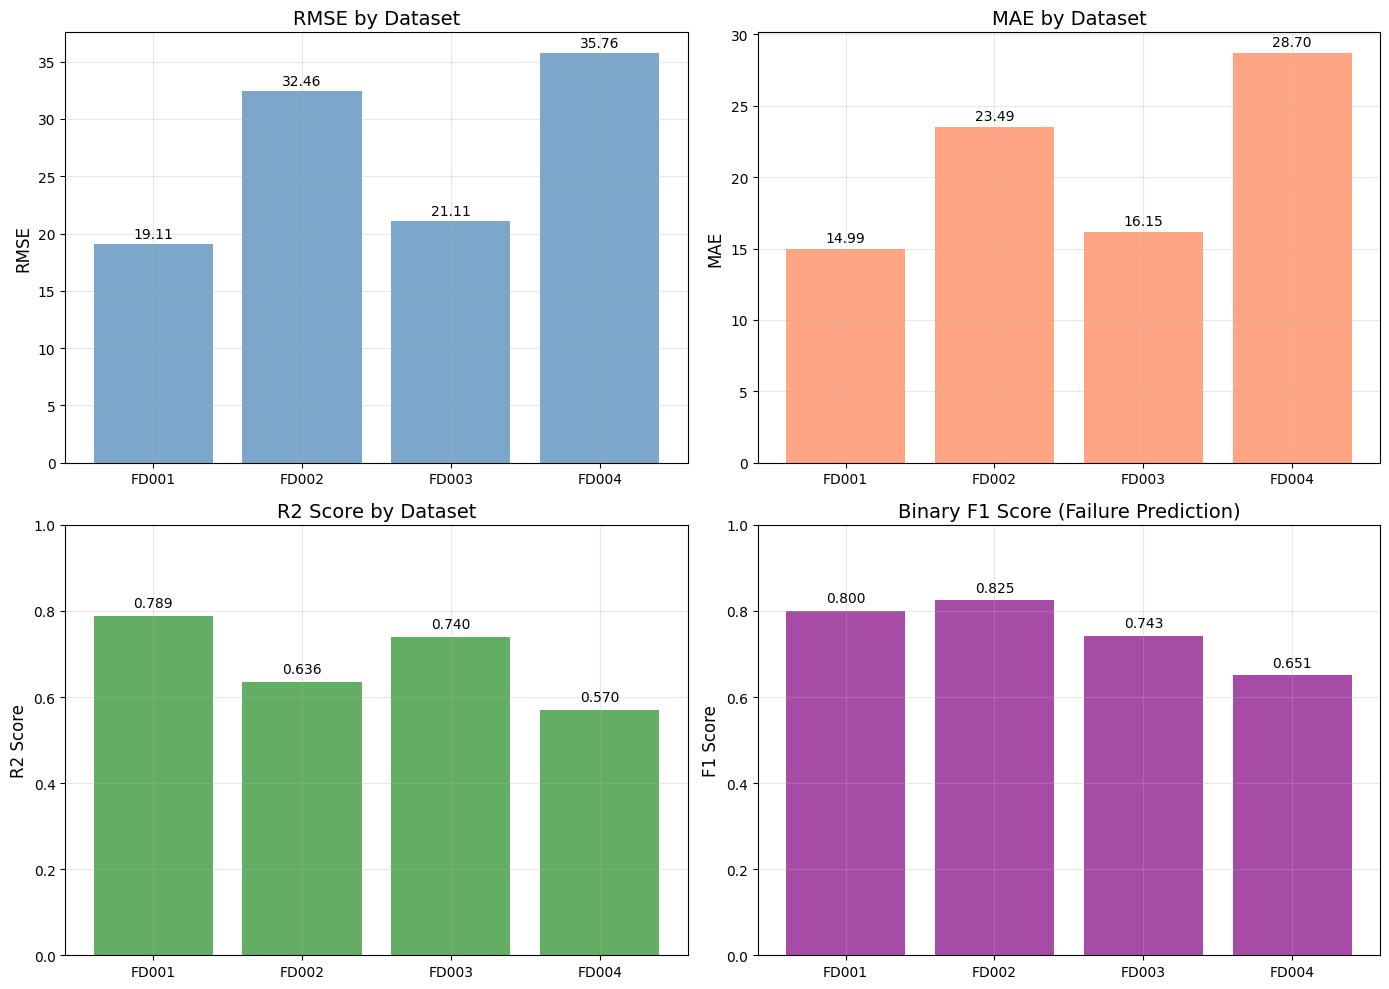

In [ ]:
# Visualization: Regression Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE
rmse_values = [all_results[d]['metrics']['RMSE'] for d in datasets_with_results]
bars1 = axes[0, 0].bar(datasets_with_results, rmse_values, color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('RMSE', fontsize=12)
axes[0, 0].set_title('RMSE by Dataset', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
for bar, v in zip(bars1, rmse_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.2f}',
                    ha='center', fontsize=10)

# MAE
mae_values = [all_results[d]['metrics']['MAE'] for d in datasets_with_results]
bars2 = axes[0, 1].bar(datasets_with_results, mae_values, color='coral', alpha=0.7)
axes[0, 1].set_ylabel('MAE', fontsize=12)
axes[0, 1].set_title('MAE by Dataset', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
for bar, v in zip(bars2, mae_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.2f}',
                    ha='center', fontsize=10)

# R2
r2_values = [all_results[d]['metrics']['R2'] for d in datasets_with_results]
bars3 = axes[1, 0].bar(datasets_with_results, r2_values, color='forestgreen', alpha=0.7)
axes[1, 0].set_ylabel('R2 Score', fontsize=12)
axes[1, 0].set_title('R2 Score by Dataset', fontsize=14)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3)
for bar, v in zip(bars3, r2_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                    ha='center', fontsize=10)

# Binary F1
f1_values = [all_results[d]['metrics']['Binary_F1'] for d in datasets_with_results]
bars4 = axes[1, 1].bar(datasets_with_results, f1_values, color='purple', alpha=0.7)
axes[1, 1].set_ylabel('F1 Score', fontsize=12)
axes[1, 1].set_title('Binary F1 Score (Failure Prediction)', fontsize=14)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
for bar, v in zip(bars4, f1_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                    ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_regression_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

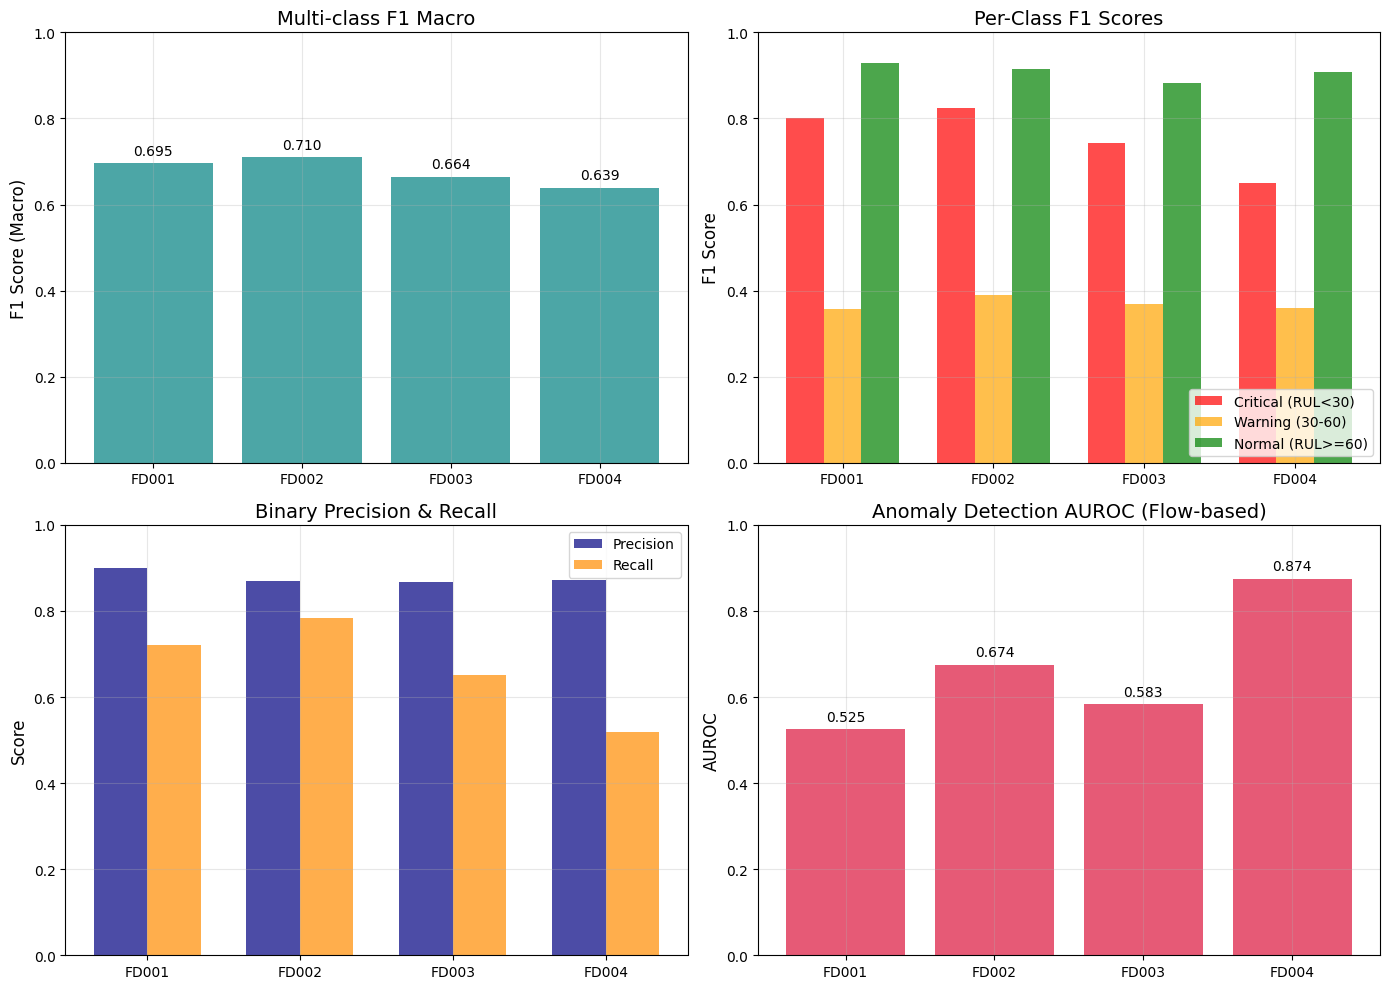

In [ ]:
# F1 Scores Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Multi-class F1 Macro
multi_f1 = [all_results[d]['metrics']['Multi_F1_Macro'] for d in datasets_with_results]
axes[0, 0].bar(datasets_with_results, multi_f1, color='teal', alpha=0.7)
axes[0, 0].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[0, 0].set_title('Multi-class F1 Macro', fontsize=14)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(multi_f1):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Per-class F1 Scores
x = np.arange(len(datasets_with_results))
width = 0.25

f1_critical = [all_results[d]['metrics']['F1_Critical'] for d in datasets_with_results]
f1_warning = [all_results[d]['metrics']['F1_Warning'] for d in datasets_with_results]
f1_normal = [all_results[d]['metrics']['F1_Normal'] for d in datasets_with_results]

axes[0, 1].bar(x - width, f1_critical, width, label='Critical (RUL<30)', color='red', alpha=0.7)
axes[0, 1].bar(x, f1_warning, width, label='Warning (30-60)', color='orange', alpha=0.7)
axes[0, 1].bar(x + width, f1_normal, width, label='Normal (RUL>=60)', color='green', alpha=0.7)
axes[0, 1].set_ylabel('F1 Score', fontsize=12)
axes[0, 1].set_title('Per-Class F1 Scores', fontsize=14)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(datasets_with_results)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# Precision and Recall
precision = [all_results[d]['metrics']['Binary_Precision'] for d in datasets_with_results]
recall = [all_results[d]['metrics']['Binary_Recall'] for d in datasets_with_results]

x = np.arange(len(datasets_with_results))
width = 0.35

axes[1, 0].bar(x - width/2, precision, width, label='Precision', color='navy', alpha=0.7)
axes[1, 0].bar(x + width/2, recall, width, label='Recall', color='darkorange', alpha=0.7)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Binary Precision & Recall', fontsize=14)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(datasets_with_results)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Anomaly Detection AUROC
auroc = [all_results[d]['metrics']['Anomaly_AUROC'] for d in datasets_with_results]
axes[1, 1].bar(datasets_with_results, auroc, color='crimson', alpha=0.7)
axes[1, 1].set_ylabel('AUROC', fontsize=12)
axes[1, 1].set_title('Anomaly Detection AUROC (Flow-based)', fontsize=14)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate(auroc):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

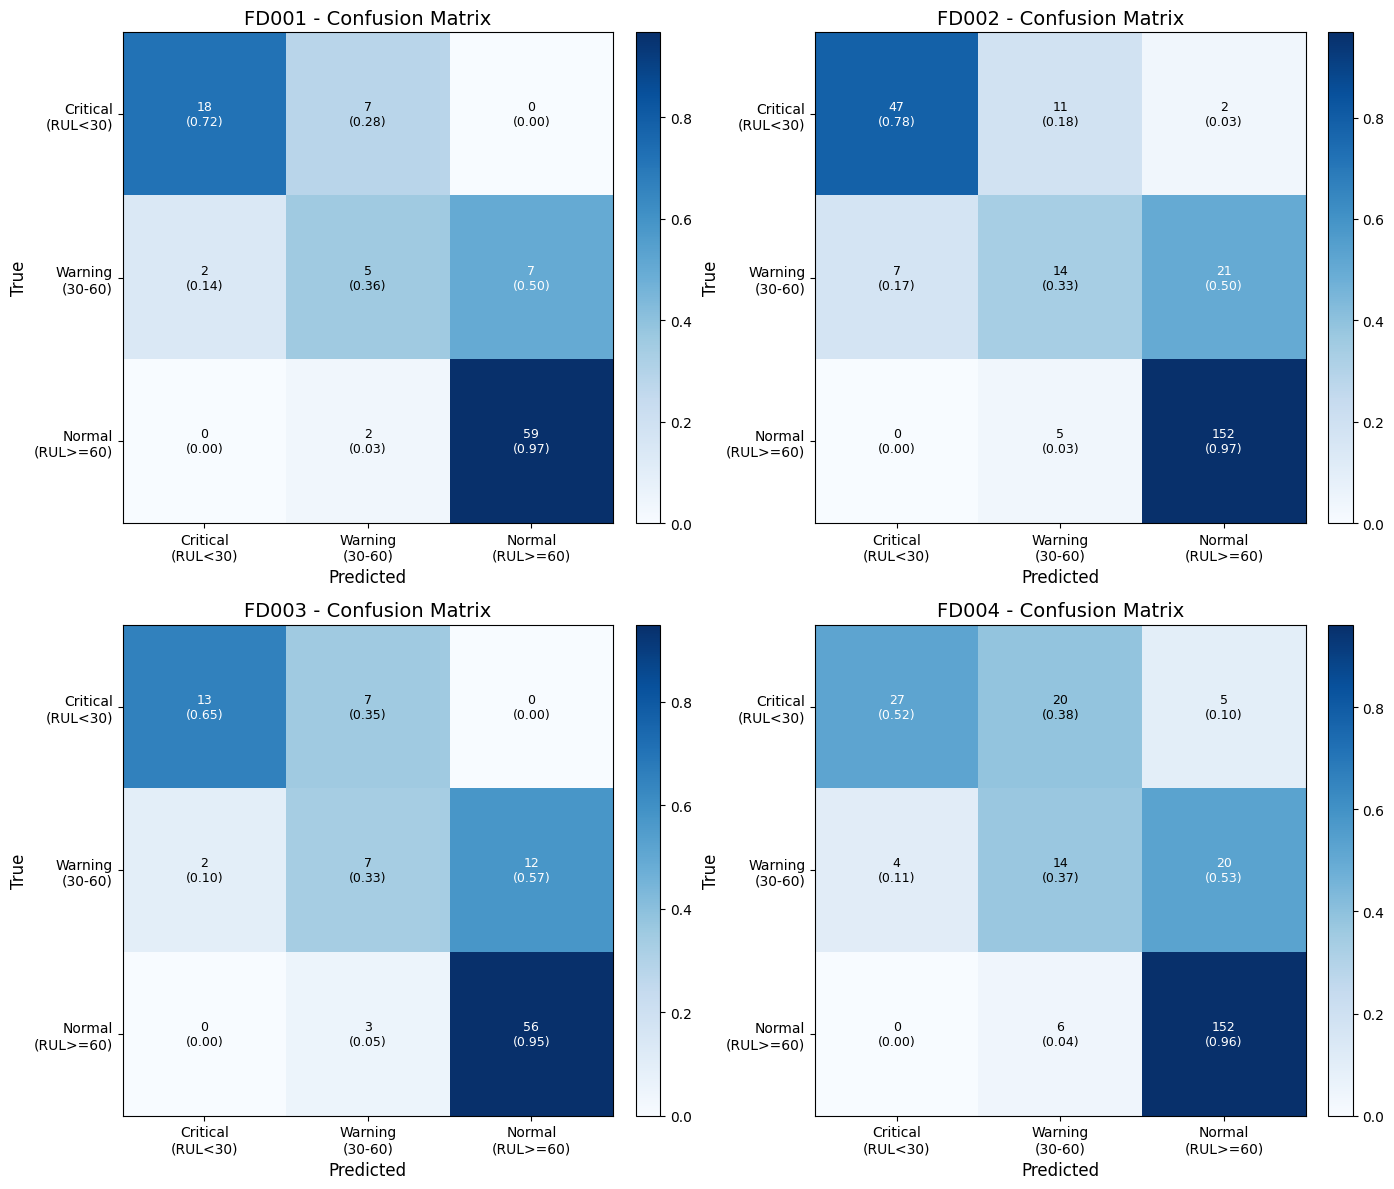

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

class_names = ['Critical\n(RUL<30)', 'Warning\n(30-60)', 'Normal\n(RUL>=60)']

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    cm = all_results[dataset]['metrics']['confusion_matrix']
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = axes[idx].imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{dataset} - Confusion Matrix', fontsize=14)
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    axes[idx].set_xticks(np.arange(len(class_names)))
    axes[idx].set_yticks(np.arange(len(class_names)))
    axes[idx].set_xticklabels(class_names)
    axes[idx].set_yticklabels(class_names)
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('True', fontsize=12)

    thresh = cm_normalized.max() / 2.
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            axes[idx].text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                          ha='center', va='center',
                          color='white' if cm_normalized[i, j] > thresh else 'black',
                          fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

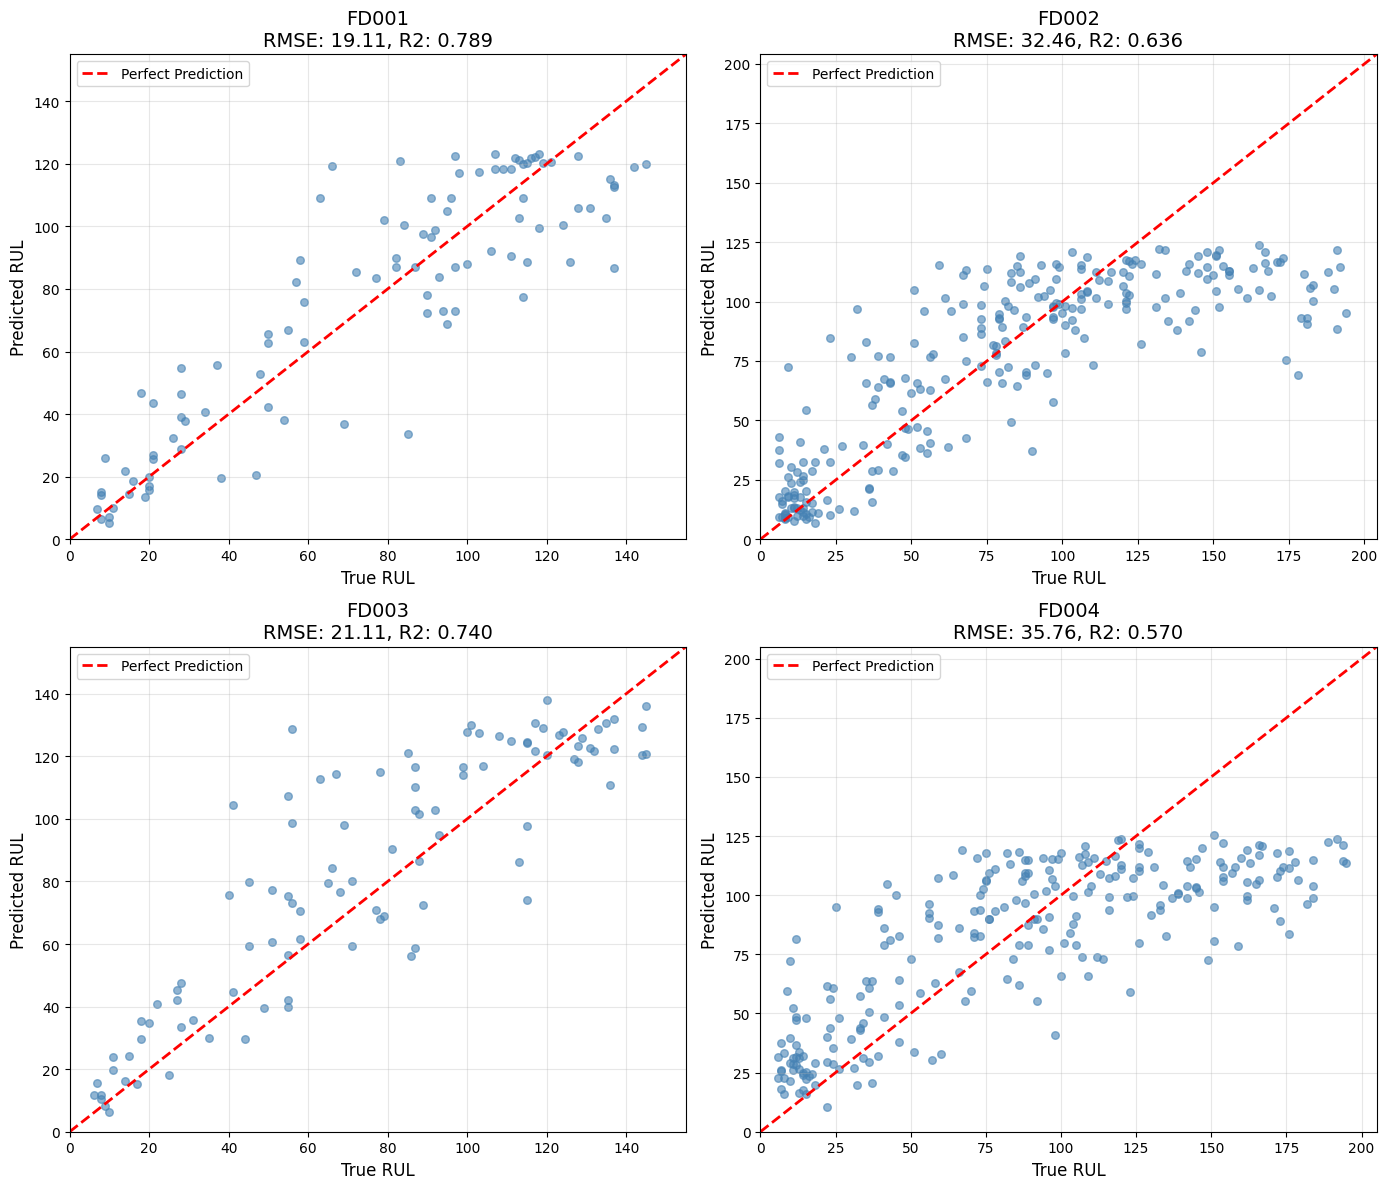

In [ ]:
# Predictions vs True RUL
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    preds = all_results[dataset]['predictions']
    targs = all_results[dataset]['targets']
    rmse = all_results[dataset]['metrics']['RMSE']
    r2 = all_results[dataset]['metrics']['R2']

    axes[idx].scatter(targs, preds, alpha=0.6, s=30, c='steelblue')
    max_val = max(max(targs), max(preds)) + 10
    axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[idx].set_xlabel('True RUL', fontsize=12)
    axes[idx].set_ylabel('Predicted RUL', fontsize=12)
    axes[idx].set_title(f'{dataset}\nRMSE: {rmse:.2f}, R2: {r2:.3f}', fontsize=14)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, max_val)
    axes[idx].set_ylim(0, max_val)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

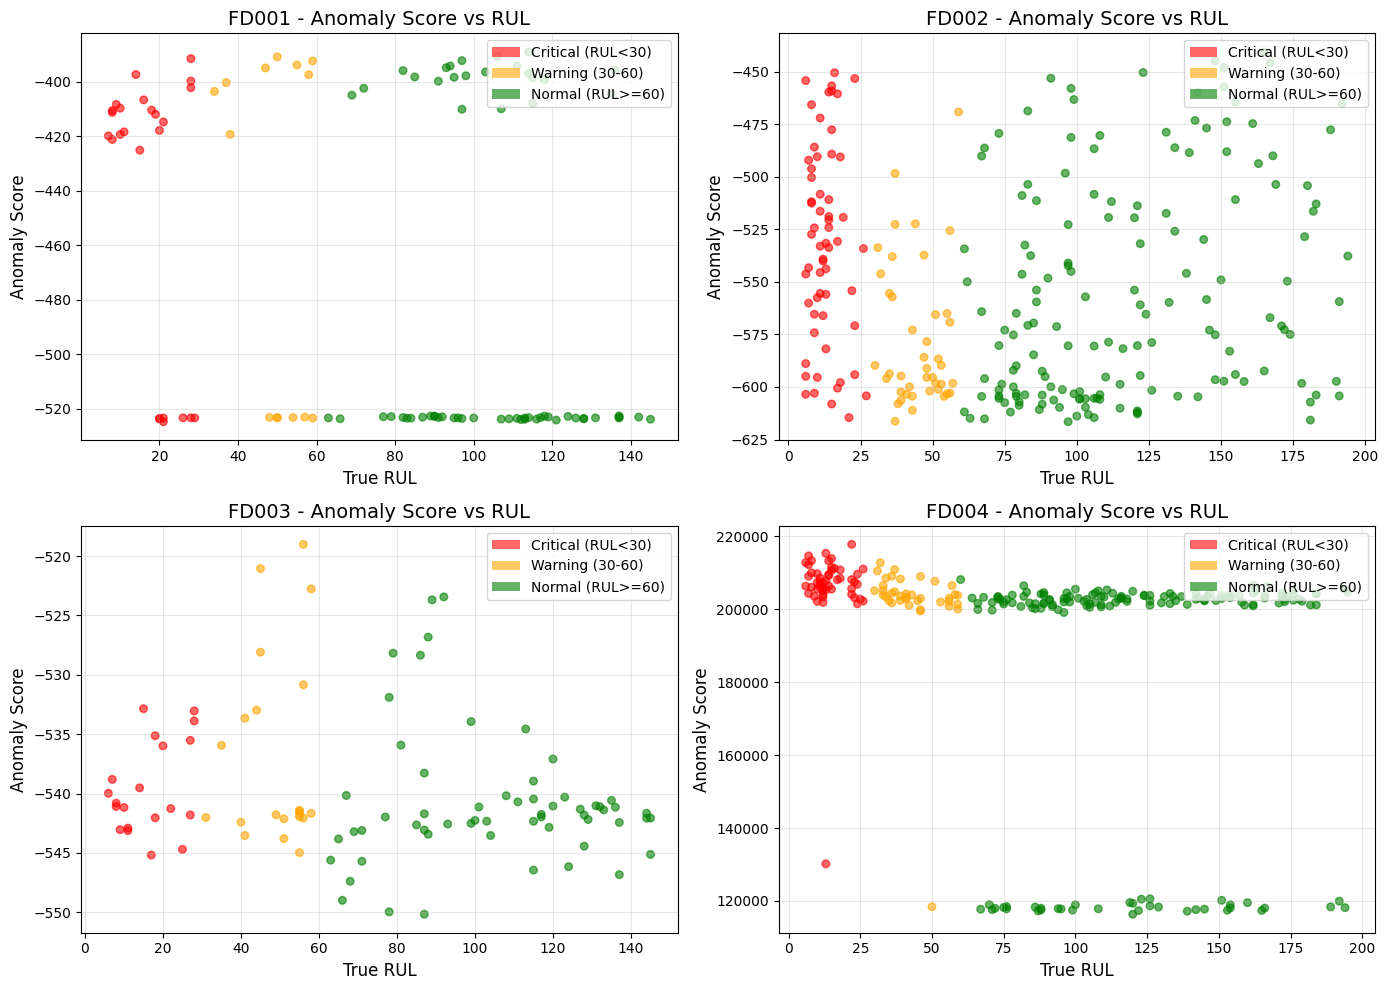

In [ ]:
# Anomaly Score Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    scores = all_results[dataset]['anomaly_scores']
    targs = all_results[dataset]['targets']

    # Color by health state
    colors = np.where(targs < 30, 'red', np.where(targs < 60, 'orange', 'green'))

    axes[idx].scatter(targs, scores, c=colors, alpha=0.6, s=30)
    axes[idx].set_xlabel('True RUL', fontsize=12)
    axes[idx].set_ylabel('Anomaly Score', fontsize=12)
    axes[idx].set_title(f'{dataset} - Anomaly Score vs RUL', fontsize=14)
    axes[idx].grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.6, label='Critical (RUL<30)'),
        Patch(facecolor='orange', alpha=0.6, label='Warning (30-60)'),
        Patch(facecolor='green', alpha=0.6, label='Normal (RUL>=60)')
    ]
    axes[idx].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

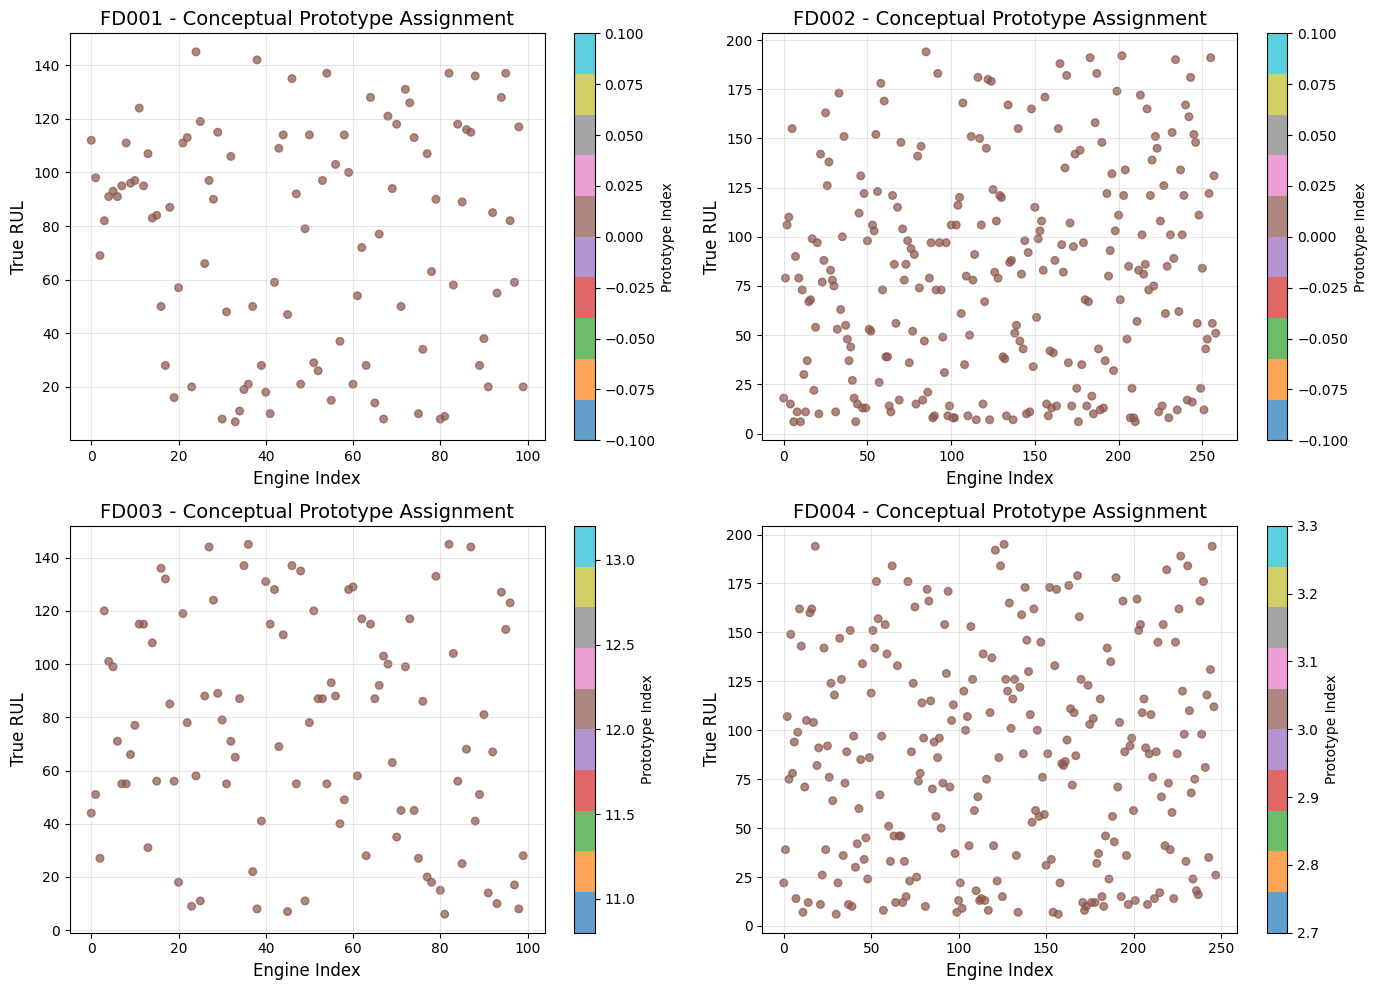

In [ ]:
# Prototype Distribution Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    proto_indices = all_results[dataset]['proto_indices']
    targs = all_results[dataset]['targets']

    # Create scatter plot colored by prototype
    scatter = axes[idx].scatter(range(len(targs)), targs, c=proto_indices,
                                 cmap='tab10', alpha=0.7, s=30)
    axes[idx].set_xlabel('Engine Index', fontsize=12)
    axes[idx].set_ylabel('True RUL', fontsize=12)
    axes[idx].set_title(f'{dataset} - Conceptual Prototype Assignment', fontsize=14)
    plt.colorbar(scatter, ax=axes[idx], label='Prototype Index')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vqflow_prototypes.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [ ]:
# Save comprehensive results to CSV

# Regression metrics
regression_data = []
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    regression_data.append({
        'Dataset': dataset,
        'RMSE': m['RMSE'],
        'MAE': m['MAE'],
        'R2': m['R2'],
        'PHM_Score': m['Score']
    })
pd.DataFrame(regression_data).to_csv('/content/drive/MyDrive/vqflow_regression_results.csv', index=False)
print("Saved: vqflow_regression_results.csv")

# Classification metrics
classification_data = []
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    classification_data.append({
        'Dataset': dataset,
        'Binary_Accuracy': m['Binary_Accuracy'],
        'Binary_Precision': m['Binary_Precision'],
        'Binary_Recall': m['Binary_Recall'],
        'Binary_F1': m['Binary_F1'],
        'Multi_Accuracy': m['Multi_Accuracy'],
        'Multi_Precision_Macro': m['Multi_Precision_Macro'],
        'Multi_Recall_Macro': m['Multi_Recall_Macro'],
        'Multi_F1_Macro': m['Multi_F1_Macro'],
        'Multi_F1_Weighted': m['Multi_F1_Weighted'],
        'F1_Critical': m['F1_Critical'],
        'F1_Warning': m['F1_Warning'],
        'F1_Normal': m['F1_Normal']
    })
pd.DataFrame(classification_data).to_csv('/content/drive/MyDrive/vqflow_classification_results.csv', index=False)
print("Saved: vqflow_classification_results.csv")

# Anomaly detection metrics
anomaly_data = []
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    anomaly_data.append({
        'Dataset': dataset,
        'Anomaly_AUROC': m['Anomaly_AUROC'],
        'Anomaly_Accuracy': m['Anomaly_Accuracy'],
        'Anomaly_Precision': m['Anomaly_Precision'],
        'Anomaly_Recall': m['Anomaly_Recall'],
        'Anomaly_F1': m['Anomaly_F1']
    })
pd.DataFrame(anomaly_data).to_csv('/content/drive/MyDrive/vqflow_anomaly_results.csv', index=False)
print("Saved: vqflow_anomaly_results.csv")

# Combined summary
combined_data = []
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    combined_data.append({
        'Dataset': dataset,
        'RMSE': m['RMSE'],
        'MAE': m['MAE'],
        'R2': m['R2'],
        'PHM_Score': m['Score'],
        'Binary_F1': m['Binary_F1'],
        'Binary_Precision': m['Binary_Precision'],
        'Binary_Recall': m['Binary_Recall'],
        'Multi_F1_Macro': m['Multi_F1_Macro'],
        'Multi_Precision_Macro': m['Multi_Precision_Macro'],
        'Multi_Recall_Macro': m['Multi_Recall_Macro'],
        'F1_Critical': m['F1_Critical'],
        'F1_Warning': m['F1_Warning'],
        'F1_Normal': m['F1_Normal'],
        'Anomaly_AUROC': m['Anomaly_AUROC'],
        'Anomaly_F1': m['Anomaly_F1']
    })
pd.DataFrame(combined_data).to_csv('/content/drive/MyDrive/vqflow_all_metrics.csv', index=False)
print("Saved: vqflow_all_metrics.csv")

# Individual predictions
for dataset in datasets_with_results:
    results_df = pd.DataFrame({
        'Engine': range(1, len(all_results[dataset]['targets']) + 1),
        'True_RUL': all_results[dataset]['targets'],
        'Predicted_RUL': all_results[dataset]['predictions'],
        'Error': all_results[dataset]['predictions'] - all_results[dataset]['targets'],
        'Anomaly_Score': all_results[dataset]['anomaly_scores'],
        'Prototype_Index': all_results[dataset]['proto_indices'],
        'True_Class': all_results[dataset]['metrics']['y_true_multi'],
        'Predicted_Class': all_results[dataset]['metrics']['y_pred_multi']
    })
    results_df.to_csv(f'/content/drive/MyDrive/vqflow_predictions_{dataset}.csv', index=False)
    print(f"Saved: vqflow_predictions_{dataset}.csv")

# Save models
for dataset in datasets_with_results:
    model_path = f'/content/drive/MyDrive/vqflow_model_{dataset}.pth'
    torch.save({
        'model_state_dict': all_results[dataset]['model'].state_dict(),
        'config': CONFIG,
        'metrics': {k: v for k, v in all_results[dataset]['metrics'].items()
                   if k not in ['confusion_matrix', 'y_true_multi', 'y_pred_multi']}
    }, model_path)
    print(f"Saved: vqflow_model_{dataset}.pth")

Saved: vqflow_regression_results.csv
Saved: vqflow_classification_results.csv
Saved: vqflow_anomaly_results.csv
Saved: vqflow_all_metrics.csv
Saved: vqflow_predictions_FD001.csv
Saved: vqflow_predictions_FD002.csv
Saved: vqflow_predictions_FD003.csv
Saved: vqflow_predictions_FD004.csv
Saved: vqflow_model_FD001.pth
Saved: vqflow_model_FD002.pth
Saved: vqflow_model_FD003.pth
Saved: vqflow_model_FD004.pth


## 11. Final Summary

In [ ]:
print("\n" + "="*100)
print("VQ-FLOW FOR TURBOFAN ENGINE ANOMALY DETECTION - FINAL SUMMARY")
print("="*100)

print("\n## Model Architecture")
print("-"*50)
print(f"Temporal Encoder: Bidirectional GRU + CNN")
print(f"CPC Size: {CONFIG['cpc_size']} prototypes, dim={CONFIG['cpc_dim']}")
print(f"CSPC Size: {CONFIG['cspc_size']} patterns, dim={CONFIG['cspc_dim']}")
print(f"Flow Layers: {CONFIG['num_flow_layers']} RealNVP layers")
print(f"Sequence Length: {CONFIG['sequence_length']}")

print("\n## Key Results")
print("-"*50)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"\n{dataset}:")
    print(f"  Regression: RMSE={m['RMSE']:.2f}, MAE={m['MAE']:.2f}, R2={m['R2']:.4f}")
    print(f"  Binary Classification: F1={m['Binary_F1']:.4f}, Precision={m['Binary_Precision']:.4f}, Recall={m['Binary_Recall']:.4f}")
    print(f"  Multi-class: F1 Macro={m['Multi_F1_Macro']:.4f}, Precision={m['Multi_Precision_Macro']:.4f}, Recall={m['Multi_Recall_Macro']:.4f}")
    print(f"  Anomaly Detection: AUROC={m['Anomaly_AUROC']:.4f}, F1={m['Anomaly_F1']:.4f}")

print("\n" + "="*100)
print("Dataset Characteristics:")
print("-"*50)
print("FD001: 1 operating condition, 1 fault mode (simplest)")
print("FD002: 6 operating conditions, 1 fault mode")
print("FD003: 1 operating condition, 2 fault modes")
print("FD004: 6 operating conditions, 2 fault modes (most complex)")

print("\n" + "="*100)
print("Health State Classification Thresholds:")
print("-"*50)
print(f"Critical: RUL < {CONFIG['critical_threshold']} cycles (imminent failure)")
print(f"Warning:  {CONFIG['critical_threshold']} <= RUL < {CONFIG['warning_threshold']} cycles")
print(f"Normal:   RUL >= {CONFIG['warning_threshold']} cycles (healthy operation)")

print("\n" + "="*100)
print("Reference:")
print("-"*50)
print("Zhou, Y., et al. (2024). 'VQ-Flow: Taming Normalizing Flows for")
print("Multi-Class Anomaly Detection via Hierarchical Vector Quantization'.")
print("IEEE Transactions on Multimedia.")
print("="*100)


VQ-FLOW FOR TURBOFAN ENGINE ANOMALY DETECTION - FINAL SUMMARY

## Model Architecture
--------------------------------------------------
Temporal Encoder: Bidirectional GRU + CNN
CPC Size: 16 prototypes, dim=64
CSPC Size: 128 patterns, dim=64
Flow Layers: 4 RealNVP layers
Sequence Length: 30

## Key Results
--------------------------------------------------

FD001:
  Regression: RMSE=19.11, MAE=14.99, R2=0.7886
  Binary Classification: F1=0.8000, Precision=0.9000, Recall=0.7200
  Multi-class: F1 Macro=0.6954, Precision=0.7170, Recall=0.6815
  Anomaly Detection: AUROC=0.5253, F1=0.0571

FD002:
  Regression: RMSE=32.46, MAE=23.49, R2=0.6357
  Binary Classification: F1=0.8246, Precision=0.8704, Recall=0.7833
  Multi-class: F1 Macro=0.7097, Precision=0.7352, Recall=0.6949
  Anomaly Detection: AUROC=0.6743, F1=0.2093

FD003:
  Regression: RMSE=21.11, MAE=16.15, R2=0.7399
  Binary Classification: F1=0.7429, Precision=0.8667, Recall=0.6500
  Multi-class: F1 Macro=0.6644, Precision=0.7007, Rec